In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 32792, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 32792 (delta 37), reused 76 (delta 21), pack-reused 32697 (from 1)
Receiving objects: 100% (32792/32792), 361.54 MiB | 45.05 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (75845/75845), done.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# --- 1. Load Datasets ---
BASE_DIR = "/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_CNN_Data"

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "val"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. Build SqueezeNet v1.1 ---
def fire_module(x, squeeze, expand):
    squeezed = layers.Conv2D(squeeze, (1, 1), activation='relu', padding='same')(x)
    e1x1 = layers.Conv2D(expand, (1, 1), activation='relu', padding='same')(squeezed)
    e3x3 = layers.Conv2D(expand, (3, 3), activation='relu', padding='same')(squeezed)
    return layers.Concatenate()([e1x1, e3x3])

def build_squeezenet(input_shape=(224, 224, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='valid', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = fire_module(x, 16, 64)
    x = fire_module(x, 16, 64)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = fire_module(x, 32, 128)
    x = fire_module(x, 32, 128)
    x = layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(x)

    x = fire_module(x, 48, 192)
    x = fire_module(x, 48, 192)
    x = fire_module(x, 64, 256)
    x = fire_module(x, 64, 256)

    x = layers.Dropout(0.5)(x)
    x = layers.Conv2D(num_classes, (1, 1), padding='valid', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)

    return models.Model(inputs, outputs)

model = build_squeezenet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. Train ---
print("Starting SqueezeNet Training...")
model.summary()

Found 17252 files belonging to 4 classes.
Found 2156 files belonging to 4 classes.
Starting SqueezeNet Training...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 55, 55,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 55, 55,    │      1,040 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 55, 55,    │      1,088 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 55, 55,    │      9,280 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 55, 55,    │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 55, 55,    │      2,064 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 55, 55,    │      1,088 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 55, 55,    │      9,280 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 55, 55,    │          0 │ conv2d_5[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 27, 27,    │          0 │ concatenate_1[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 27, 27,    │      4,128 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 27, 27,    │      4,224 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 27, 27,    │     36,992 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 27, 27,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 27, 27,    │      8,224 │ concatenate_2[0]

 Total params: 724,548 (2.76 MB)

 Trainable params: 724,548 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Epoch 1/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - accuracy: 0.5449 - loss: 0.9627 - val_accuracy: 0.6197 - val_loss: 0.8000
Epoch 2/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.6804 - loss: 0.7285 - val_accuracy: 0.6545 - val_loss: 0.7560
Epoch 3/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7288 - loss: 0.6482 - val_accuracy: 0.6878 - val_loss: 0.7118
Epoch 4/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.7497 - loss: 0.5891 - val_accuracy: 0.7194 - val_loss: 0.6881
Epoch 5/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.7641 - loss: 0.5636 - val_accuracy: 0.7551 - val_loss: 0.5755
Epoch 6/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7755 - loss: 0.5411 - val_accuracy: 0.7426 - val_loss: 0.6027
Epoch 7/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7877 - loss: 0.5143 - val_accuracy: 0.7801 - val_loss: 0.5237
Epoch 8/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7892 - loss: 0.5014 - 

Found 2160 files belonging to 4 classes.
Evaluating SqueezeNet...
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step


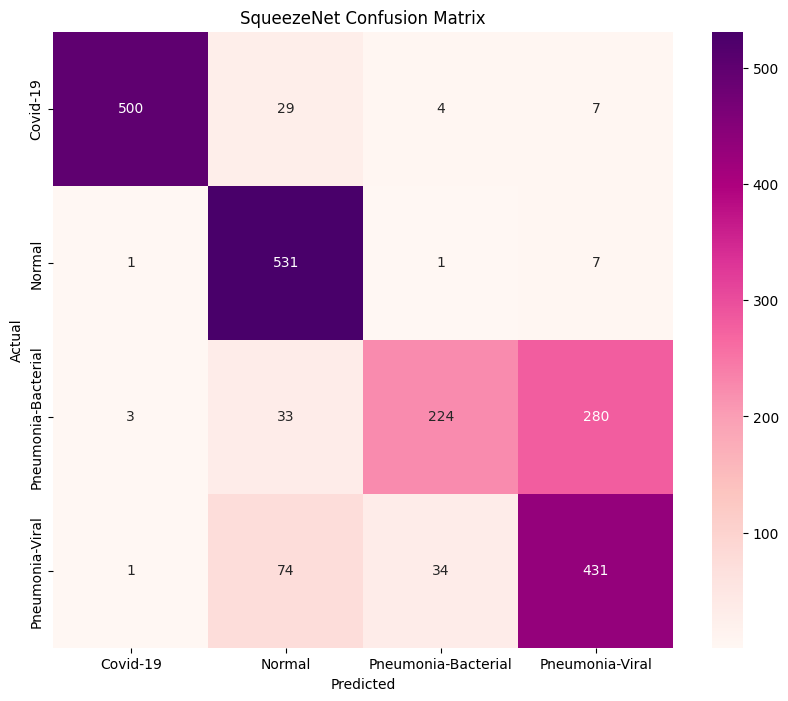


Classification Report:

                     precision    recall  f1-score   support

           Covid-19       0.99      0.93      0.96       540
             Normal       0.80      0.98      0.88       540
Pneumonia-Bacterial       0.85      0.41      0.56       540
    Pneumonia-Viral       0.59      0.80      0.68       540

           accuracy                           0.78      2160
          macro avg       0.81      0.78      0.77      2160
       weighted avg       0.81      0.78      0.77      2160



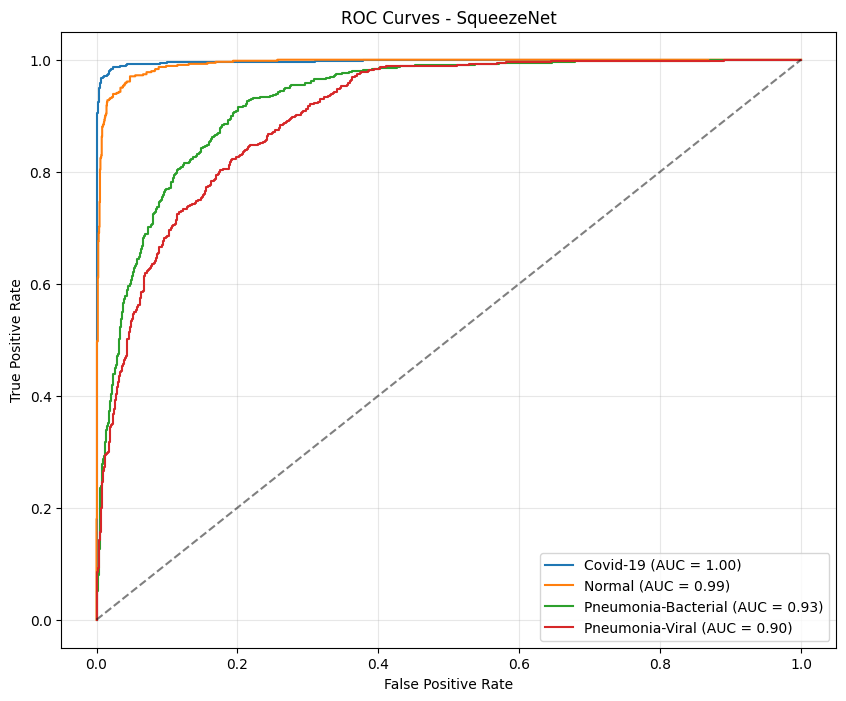

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 1. Load Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

# 2. Generate Predictions
print("Evaluating SqueezeNet...")
y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Metric A: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SqueezeNet Confusion Matrix')
plt.show()

# --- Metric B: Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Metric C: ROC Curves & AUC ---
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    y_true_bin = to_categorical(y_true, num_classes=4)[:, i]
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - SqueezeNet')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()